Task 1: Load the dataset into a Pandas DataFrame.

In [52]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/tstef87/StefanoCSC672/refs/heads/master/HW3/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(url)

Task 2: Use structural inspection methods (head(), info(), describe()) to analyze features such as tenure, MonthlyCharges, TotalCharges, Contract, and PaymentMethod.

In [53]:
# Display Data Frame Head
print("\n --- DF Head ---")
print(df.head())

# Display Data Frame Info
print("\n --- DF INFO ---")
df.info()

# Display Summary Statistics
print("\n --- Summary Statistics ---")
display(df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'PaymentMethod']].describe(include='all'))


 --- DF Head ---
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies   

,tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod
count,7043.000000,7043.000000,7043,7043,7043
unique,NaN,NaN,6531,3,4
top,NaN,NaN,,Month-to-month,Electronic check
freq,NaN,NaN,11,3875,2365
mean,32.371149,64.761692,NaN,NaN,NaN
std,24.559481,30.090047,NaN,NaN,NaN
min,0.000000,18.250000,NaN,NaN,NaN
25%,9.000000,35.500000,NaN,NaN,NaN
50%,29.000000,70.350000,NaN,NaN,NaN
75%,55.000000,89.850000,NaN,NaN,NaN


Task 3: Drop any non-informative identifiers (such as customerID).

In [54]:
df = df.drop(columns=['customerID'])

Task 4: Quantify any missing or implicit missing values across the columns (handling whitespace strings in TotalCharges) and implement a structured imputation strategy using Scikit-Learn's SimpleImputer.

In [55]:
from sklearn.impute import SimpleImputer

# find Null values 
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [56]:
# Strip Whitespaces 
p_df = df['TotalCharges'].str.strip() == ''
print(p_df.sum())
df[p_df]

11


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


When Tenur is 0, Total Cost is blank.

In [57]:
# Change Total cost from object to numeric value
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# find Null values 
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [58]:
# Make Null Values = 0
imputer = SimpleImputer(strategy='constant', fill_value = 0)
df['TotalCharges'] = imputer.fit_transform(df[['TotalCharges']]).ravel()

# find Null values 
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


Task 5: Isolate numerical and categorical features, then build a Scikit-Learn ColumnTransformer and Pipeline that applies appropriate scaling (StandardScaler or MinMaxScaler) to numerical columns and encoding (OneHotEncoder) to categorical columns.

In [59]:
y = df['Churn']
X = df.drop(columns=['Churn'])

num_data = X.select_dtypes(include=['int64', 'float64'])
cat_data = X.select_dtypes(include=['object'])

print("\n--- Numeric Data ---")
print(num_data)

print("\n--- Categorical Data ---")
print(cat_data)


--- Numeric Data ---
      SeniorCitizen  tenure  MonthlyCharges  TotalCharges
0                 0       1           29.85         29.85
1                 0      34           56.95       1889.50
2                 0       2           53.85        108.15
3                 0      45           42.30       1840.75
4                 0       2           70.70        151.65
...             ...     ...             ...           ...
7038              0      24           84.80       1990.50
7039              0      72          103.20       7362.90
7040              0      11           29.60        346.45
7041              1       4           74.40        306.60
7042              0      66          105.65       6844.50

[7043 rows x 4 columns]

--- Categorical Data ---
      gender Partner Dependents PhoneService     MultipleLines  \
0     Female     Yes         No           No  No phone service   
1       Male      No         No          Yes                No   
2       Male      No         No  

In [68]:
# Import Libs 
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline, Pipeline

num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"), 
    StandardScaler())

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"))

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_data.columns.tolist()),
    ("cat", cat_pipeline, cat_data.columns.tolist()),
])

Task 6: Append an SGDClassifier configured with loss='log_loss' to the end of your pipeline to perform logistic regression and enable probability estimation.

In [69]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(loss='log_loss', random_state=42)
full_pipeline = make_pipeline(preprocessing, sgd_clf)

Task 7: Split your dataset into training and test sets using 3 different train/test split ratios (for example, 80/20, 70/30, and 60/40), fit your complete pipeline on each configuration, and evaluate performance using a confusion matrix, classification report, and ROC-AUC curve. Report on any performance differences detected across the various splitting ratios.

In [70]:
from sklearn.model_selection import train_test_split

# 80/20 
X_train_8020, X_test_8020, y_train_8020, y_test_8020 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 70/30 
X_train_7030, X_test_7030, y_train_7030, y_test_7030 = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 60/40 
X_train_6040, X_test_6040, y_train_6040, y_test_6040 = train_test_split(
    X, y, test_size=0.4, random_state=42
)

In [71]:
# 80/20
full_pipeline.fit(X_train_8020, y_train_8020)
y_pred_8020 = full_pipeline.predict(X_test_8020)
y_proba_8020 = full_pipeline.predict_proba(X_test_8020)[:, 1]

# 70/30
full_pipeline.fit(X_train_7030, y_train_7030)
y_pred_7030 = full_pipeline.predict(X_test_7030)
y_proba_7030 = full_pipeline.predict_proba(X_test_7030)[:, 1]

# 60/40
full_pipeline.fit(X_train_6040, y_train_6040)
y_pred_6040 = full_pipeline.predict(X_test_6040)
y_proba_6040 = full_pipeline.predict_proba(X_test_6040)[:, 1]

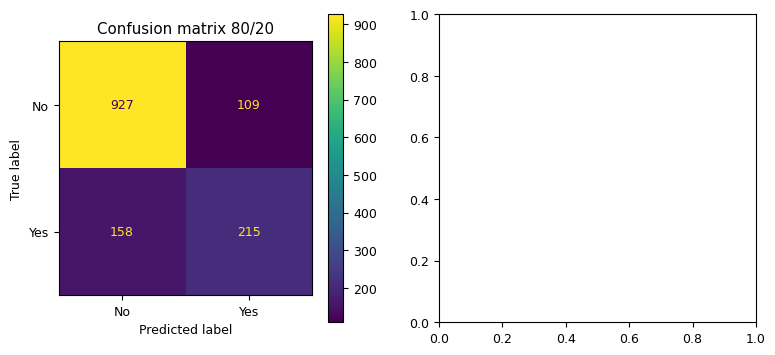

In [73]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, ConfusionMatrixDisplay

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
plt.rc('font', size=9)
ConfusionMatrixDisplay.from_predictions(y_test_8020, y_pred_8020, ax=axs[0])
axs[0].set_title("Confusion matrix 80/20")
plt.rc('font', size=10)